In [18]:
from google.colab import drive; drive.mount('/content/drive')
import os
BASE = '/content/drive/MyDrive/Mental-Health'
DAIC = os.path.join(BASE, 'DAIC')
OUT  = os.path.join(BASE, 'outputs', 'voice'); os.makedirs(OUT, exist_ok=True)
print('DAIC exists:', os.path.isdir(DAIC))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DAIC exists: True


In [19]:
!pip install -q xgboost scikit-learn scipy joblib shap
import xgboost as xgb, sklearn
print('XGBoost:', xgb.__version__, '| sklearn:', sklearn.__version__)

XGBoost: 3.2.0 | sklearn: 1.6.1


In [20]:
import os, json, random, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, joblib
from scipy.stats import skew, kurtosis
from tqdm.notebook import tqdm
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt, seaborn as sns

BINARY_THR = 10
SEED       = 42
MAX_NAN_FRAC = 0.20
TOP_K_FEATURES = 80
CLASS_NAMES = ['Not depressed', 'Depressed']
random.seed(SEED); np.random.seed(SEED)
print('Imports done')

Imports done


## Step 1 — Load labels (binary)

In [21]:
def load_labels(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]
    phq = next((c for c in df.columns if 'phq' in c and ('score' in c or '8' in c)), None)
    if phq is None: phq = next((c for c in df.columns if 'phq' in c), None)
    pid = next((c for c in df.columns if 'participant' in c or c=='id'), None)
    df['label'] = (df[phq].astype(float) >= BINARY_THR).astype(int)
    df = df.rename(columns={pid:'participant_id', phq:'phq_score'})
    df = df[['participant_id','phq_score','label']].dropna()
    df['participant_id'] = df['participant_id'].astype(int)
    print(f'Labels: {len(df)} | class 0: {(df.label==0).sum()} | class 1: {(df.label==1).sum()}')
    return df

labels_df = load_labels(os.path.join(DAIC, 'labels.csv'))

Labels: 142 | class 0: 99 | class 1: 43


## Step 2 — Aggregate voice features (9 statistics)

In [22]:
def safe_slope(arr):
    """Linear regression slope over time — captures trend in voice dynamics."""
    if len(arr) < 2: return 0.0
    x = np.arange(len(arr))
    try:
        p = np.polyfit(x, arr, 1)
        return p[0]
    except: return 0.0

def aggregate_features(df, prefix):
    """9-statistic aggregation per feature column."""
    # Replace sentinel values
    df = df.replace([999.0, -999.0, 0.0], np.nan)
    feat = {}
    for ci in range(df.shape[1]):
        col = df.iloc[:, ci].values.astype(float)
        col = col[~np.isnan(col)]
        k   = f'{prefix}_f{ci}'
        if len(col) == 0:
            for s in ['mean','std','min','max','med','iqr','skew','kurt','slope']:
                feat[f'{k}_{s}'] = np.nan
            continue
        feat[f'{k}_mean']  = float(np.mean(col))
        feat[f'{k}_std']   = float(np.std(col))
        feat[f'{k}_min']   = float(np.min(col))
        feat[f'{k}_max']   = float(np.max(col))
        feat[f'{k}_med']   = float(np.median(col))
        feat[f'{k}_iqr']   = float(np.percentile(col,75) - np.percentile(col,25))
        feat[f'{k}_skew']  = float(skew(col))   if len(col)>2 else 0.0
        feat[f'{k}_kurt']  = float(kurtosis(col)) if len(col)>2 else 0.0
        feat[f'{k}_slope'] = float(safe_slope(col))
    return feat

def load_voice_features(daic_dir, labels_df):
    lut  = labels_df.set_index('participant_id')
    dirs = sorted([d for d in os.listdir(daic_dir)
                   if os.path.isdir(os.path.join(daic_dir,d)) and d.endswith('_P')])
    print(f'Patient folders: {len(dirs)}')
    records = []
    for folder in tqdm(dirs, desc='Voice features'):
        try: pid = int(folder.split('_')[0])
        except: continue
        if pid not in lut.index: continue
        pdir = os.path.join(daic_dir, folder)
        feat = {'participant_id': pid}
        loaded = False
        for fname, prefix in [(f'{pid}_COVAREP.csv','cov'), (f'{pid}_FORMANT.csv','fmt')]:
            fp = os.path.join(pdir, fname)
            if not os.path.exists(fp): continue
            try:
                df = pd.read_csv(fp, header=None)
                feat.update(aggregate_features(df, prefix))
                loaded = True
            except Exception as e:
                print(f'  Error {pid}/{fname}: {e}')
        if not loaded: continue
        row = lut.loc[pid]
        feat['label']     = int(row['label'])
        feat['phq_score'] = float(row['phq_score'])
        records.append(feat)

    result = pd.DataFrame(records)
    print(f'\nRaw matrix: {result.shape}')

    # Strict NaN filtering
    meta = ['participant_id','label','phq_score']
    fcols = [c for c in result.columns if c not in meta]
    nan_frac = result[fcols].isna().mean()
    keep = nan_frac[nan_frac <= MAX_NAN_FRAC].index.tolist()
    result = result[meta + keep]
    result[keep] = result[keep].fillna(result[keep].median())
    print(f'After NaN filter: {result.shape} ({len(keep)} features)')
    return result, keep

voice_df, feat_cols = load_voice_features(DAIC, labels_df)
voice_df.to_csv(os.path.join(OUT, 'voice_features.csv'), index=False)
print('Saved voice_features.csv')

Patient folders: 189


Voice features:   0%|          | 0/189 [00:00<?, ?it/s]


Raw matrix: (142, 714)
After NaN filter: (142, 649) (646 features)
Saved voice_features.csv


## Step 3 — Feature selection (variance + mutual information)

In [23]:
meta = ['participant_id','label','phq_score']
X_all = voice_df[feat_cols].values
y_all = voice_df['label'].values
X_all[np.isinf(X_all)] = np.nan

for i in range(X_all.shape[1]):
    if np.any(np.isnan(X_all[:, i])):
        col_median = np.nanmedian(X_all[:, i])
        if np.isnan(col_median):
            X_all[:, i] = 0.0
        else:
            X_all[:, i][np.isnan(X_all[:, i])] = col_median

vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X_all)
kept_after_vt = [feat_cols[i] for i in range(len(feat_cols)) if vt.get_support()[i]]
print(f'After variance threshold: {X_vt.shape[1]} features (was {len(feat_cols)})')

mi_scores = mutual_info_classif(X_vt, y_all, random_state=SEED, n_neighbors=3)
top_k = min(TOP_K_FEATURES, X_vt.shape[1])
top_idx = np.argsort(mi_scores)[::-1][:top_k]
feat_cols_selected = [kept_after_vt[i] for i in top_idx]
X_sel = X_vt[:, top_idx]
print(f'After MI selection (top {top_k}): {X_sel.shape[1]} features')

print('\nTop 10 features by mutual information:')
for i in range(min(10, len(feat_cols_selected))):
    print(f'  {feat_cols_selected[i]:<40}  MI={mi_scores[top_idx[i]]:.4f}')

After variance threshold: 328 features (was 646)
After MI selection (top 80): 80 features

Top 10 features by mutual information:
  fmt_f2_skew                               MI=0.1571
  cov_f22_kurt                              MI=0.1418
  cov_f44_kurt                              MI=0.1171
  cov_f44_skew                              MI=0.1039
  cov_f5_skew                               MI=0.0911
  cov_f51_iqr                               MI=0.0898
  cov_f8_kurt                               MI=0.0891
  cov_f11_max                               MI=0.0863
  cov_f70_skew                              MI=0.0836
  cov_f23_min                               MI=0.0784


## Step 4 — Split + normalize

In [24]:
df_idx = np.arange(len(voice_df))
tv_idx, test_idx = train_test_split(df_idx, test_size=0.15, stratify=y_all, random_state=SEED)
tr_idx, val_idx  = train_test_split(tv_idx, test_size=0.15/0.85, stratify=y_all[tv_idx], random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_sel[tr_idx]);  y_train = y_all[tr_idx]
X_val   = scaler.transform(X_sel[val_idx]);      y_val   = y_all[val_idx]
X_test  = scaler.transform(X_sel[test_idx]);     y_test  = y_all[test_idx]

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Train class dist: {np.bincount(y_train)}')

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
sw = np.array([cw[y] for y in y_train])
print(f'Class weights: {cw.round(3)}')

Train: 98 | Val: 22 | Test: 22
Train class dist: [69 29]
Class weights: [0.71 1.69]


## Step 5 — Train XGBoost

In [25]:
xgb_model = XGBClassifier(
    n_estimators=700,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=cw[1]/cw[0],  # handles imbalance directly
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=SEED,
    tree_method='hist'
)
xgb_model.fit(
    X_train, y_train,
    sample_weight=sw,
    eval_set=[(X_val, y_val)],
    verbose=100
)
print(f'Best iteration: {xgb_model.best_iteration}')

[0]	validation_0-auc:0.64762
[39]	validation_0-auc:0.68571
Best iteration: 9


## Step 6 — Train SVM

In [26]:
from sklearn.svm import SVC
svm_model = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=SEED
)
svm_model.fit(X_train, y_train)
print('SVM trained')

SVM trained


## Step 7 — Soft-vote ensemble + evaluate

In [27]:
xgb_prob  = xgb_model.predict_proba(X_test)
svm_prob  = svm_model.predict_proba(X_test)
ens_prob  = (xgb_prob + svm_prob) / 2.0
ens_pred  = ens_prob.argmax(axis=1)

xgb_pred = xgb_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

results = {}
for name, pred, prob in [
    ('XGBoost',  xgb_pred, xgb_prob[:,1]),
    ('SVM',      svm_pred, svm_prob[:,1]),
    ('Ensemble', ens_pred, ens_prob[:,1])
]:
    results[name] = {
        'accuracy': float(accuracy_score(y_test, pred)),
        'f1':       float(f1_score(y_test, pred, average='weighted', zero_division=0)),
        'f1_pos':   float(f1_score(y_test, pred, pos_label=1, average='binary', zero_division=0)),
        'roc_auc':  float(roc_auc_score(y_test, prob))
    }
    print(f'{name}: acc={results[name]["accuracy"]:.4f}  F1={results[name]["f1"]:.4f}  AUC={results[name]["roc_auc"]:.4f}')

best_name = max(results, key=lambda k: results[k]['f1'])
print(f'\n🏆 Best: {best_name}')
print(classification_report(y_test, ens_pred, target_names=CLASS_NAMES, zero_division=0))

with open(os.path.join(OUT,'voice_metrics.json'),'w') as f:
    json.dump({'voice': results[best_name]}, f, indent=2)

XGBoost: acc=0.3182  F1=0.1536  AUC=0.5143
SVM: acc=0.7273  F1=0.7131  AUC=0.6571
Ensemble: acc=0.7273  F1=0.7273  AUC=0.6381

🏆 Best: Ensemble
               precision    recall  f1-score   support

Not depressed       0.80      0.80      0.80        15
    Depressed       0.57      0.57      0.57         7

     accuracy                           0.73        22
    macro avg       0.69      0.69      0.69        22
 weighted avg       0.73      0.73      0.73        22



## Step 8 — 5-fold cross-validation

In [28]:
print('Running 5-fold CV on XGBoost...')
kf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_tv  = np.vstack([X_train, X_val])
y_tv  = np.concatenate([y_train, y_val])

cv_xgb = XGBClassifier(n_estimators=xgb_model.best_iteration,
    max_depth=5, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=cw[1]/cw[0], random_state=SEED, tree_method='hist', eval_metric='auc')

cv_scores = cross_val_score(cv_xgb, X_tv, y_tv, cv=kf, scoring='f1_weighted', n_jobs=-1)
print(f'5-Fold CV F1: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Running 5-fold CV on XGBoost...
5-Fold CV F1: [0.7395 0.6815 0.6318 0.6318 0.7866]
Mean: 0.6942 ± 0.0609


## Step 9 — Plots: confusion matrix, ROC, feature importance

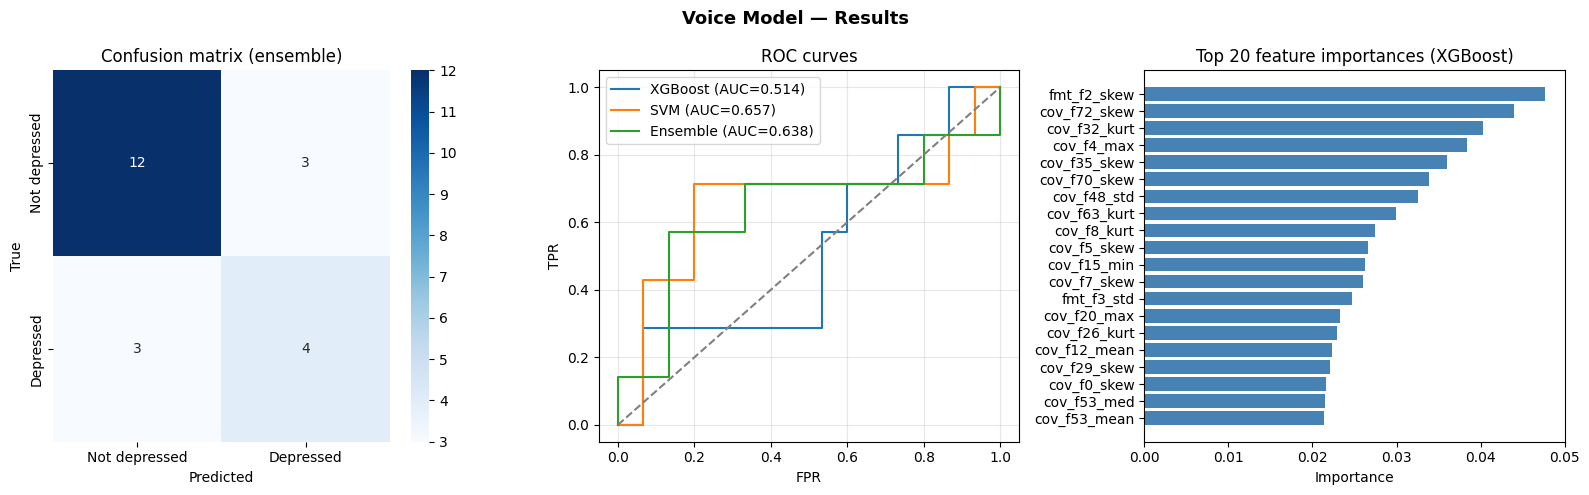

In [29]:
fig, axes = plt.subplots(1,3, figsize=(16,5))

# Confusion matrix
cm = confusion_matrix(y_test, ens_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion matrix (ensemble)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# ROC curves
for name, prob in [('XGBoost', xgb_prob[:,1]), ('SVM', svm_prob[:,1]), ('Ensemble', ens_prob[:,1])]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', lw=1.5)
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title('ROC curves'); axes[1].legend(); axes[1].grid(alpha=.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')

# Feature importance
fi = xgb_model.feature_importances_
top = np.argsort(fi)[::-1][:20]
axes[2].barh([feat_cols_selected[i][:30] for i in top[::-1]], fi[top[::-1]], color='steelblue')
axes[2].set_title('Top 20 feature importances (XGBoost)')
axes[2].set_xlabel('Importance')

plt.suptitle('Voice Model — Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT,'voice_results.png'), dpi=150)
plt.show()

## Step 10 — Save models + extract embeddings

In [30]:
joblib.dump(xgb_model,           os.path.join(OUT,'voice_xgb.pkl'))
joblib.dump(svm_model,           os.path.join(OUT,'voice_svm.pkl'))
joblib.dump(scaler,              os.path.join(OUT,'voice_scaler.pkl'))
with open(os.path.join(OUT,'voice_features.json'),'w') as f:
    json.dump(feat_cols_selected, f)
print('Models saved')

X_all_sel    = scaler.transform(X_sel)
xgb_emb = xgb_model.predict_proba(X_all_sel)
svm_emb = svm_model.predict_proba(X_all_sel)
voice_emb = (xgb_emb + svm_emb) / 2.0

all_ids = voice_df['participant_id'].values
np.savez(os.path.join(OUT,'voice_embeddings.npz'), embeddings=voice_emb, ids=all_ids)
print(f'Voice embeddings: {voice_emb.shape}')
print(f'\nAll output files:')
for f in sorted(os.listdir(OUT)):
    print(f'  {f:<40} {os.path.getsize(os.path.join(OUT,f))/1e6:.2f} MB')

Models saved
Voice embeddings: (142, 2)

All output files:
  voice_embeddings.npz                     0.00 MB
  voice_features.csv                       1.43 MB
  voice_features.json                      0.00 MB
  voice_metrics.json                       0.00 MB
  voice_results.png                        0.16 MB
  voice_scaler.pkl                         0.00 MB
  voice_svm.pkl                            0.06 MB
  voice_xgb.pkl                            0.04 MB
